# SST (Small-Sized Telescope)

SST_like configuration with the CHEC-S camera style

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope, show_camera, show_telescope

## Load telescope and camera

In [2]:
telescope = Telescope.from_yaml(
    '../../configs/CTAO/SST_like.yaml',
    n_samples=256,
    key=jax.random.key(42),
)
camera = Camera.from_yaml('../../configs/CTAO/CHECS.yaml')

E0619 12:38:00.649603 1552930 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0619 12:38:00.649728 1552931 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0619 12:38:00.649764 1552932 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## 3D scene

In [3]:
scene = show_telescope(telescope, camera=camera)
scene.show(viewer='jupyter')

## Star field image

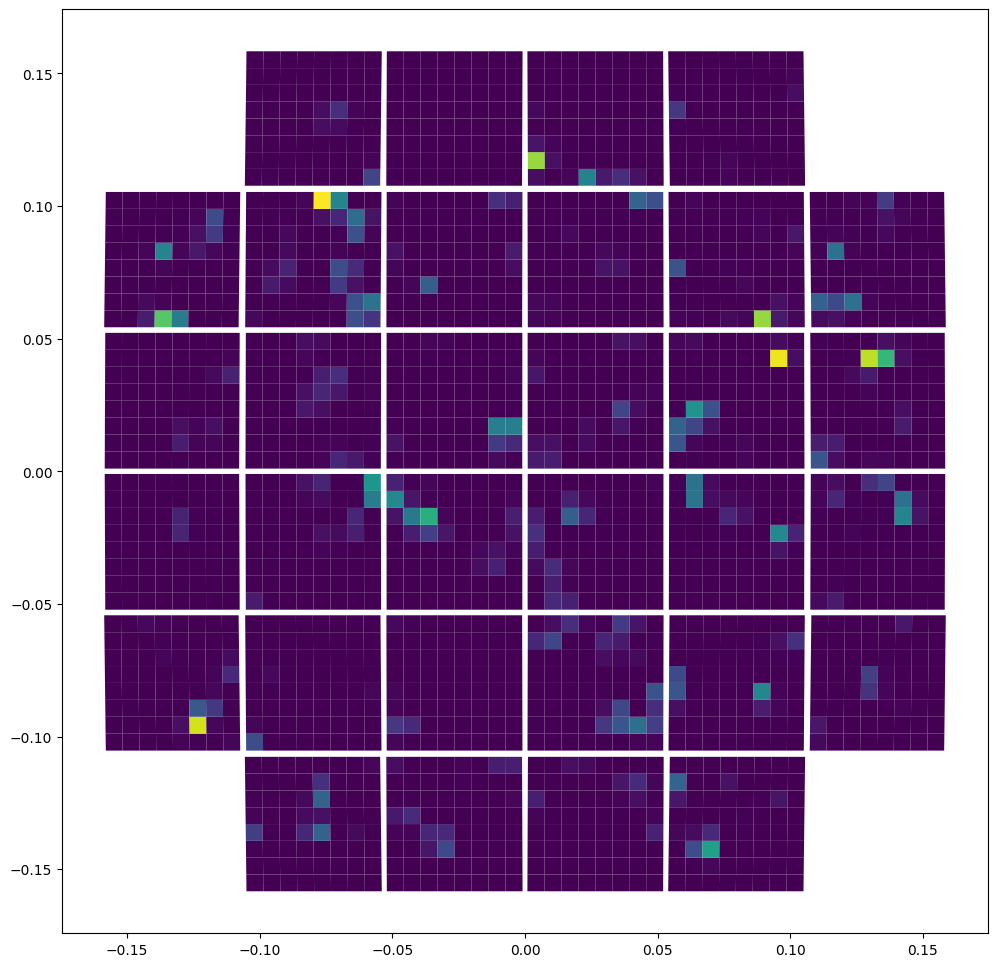

In [4]:
n_stars = 1000
key1, key2 = jax.random.split(jax.random.key(42))

fov_deg = 7.7
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

f_stars = 10**(-10 * jax.random.uniform(jax.random.key(4242), shape=(len(stars),)))

rays = telescope.render(stars, f_stars, source_type='parallel')
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_camera(image, camera.sensor_groups[0], ax=ax)

## Bokeh from a finite-distance point source

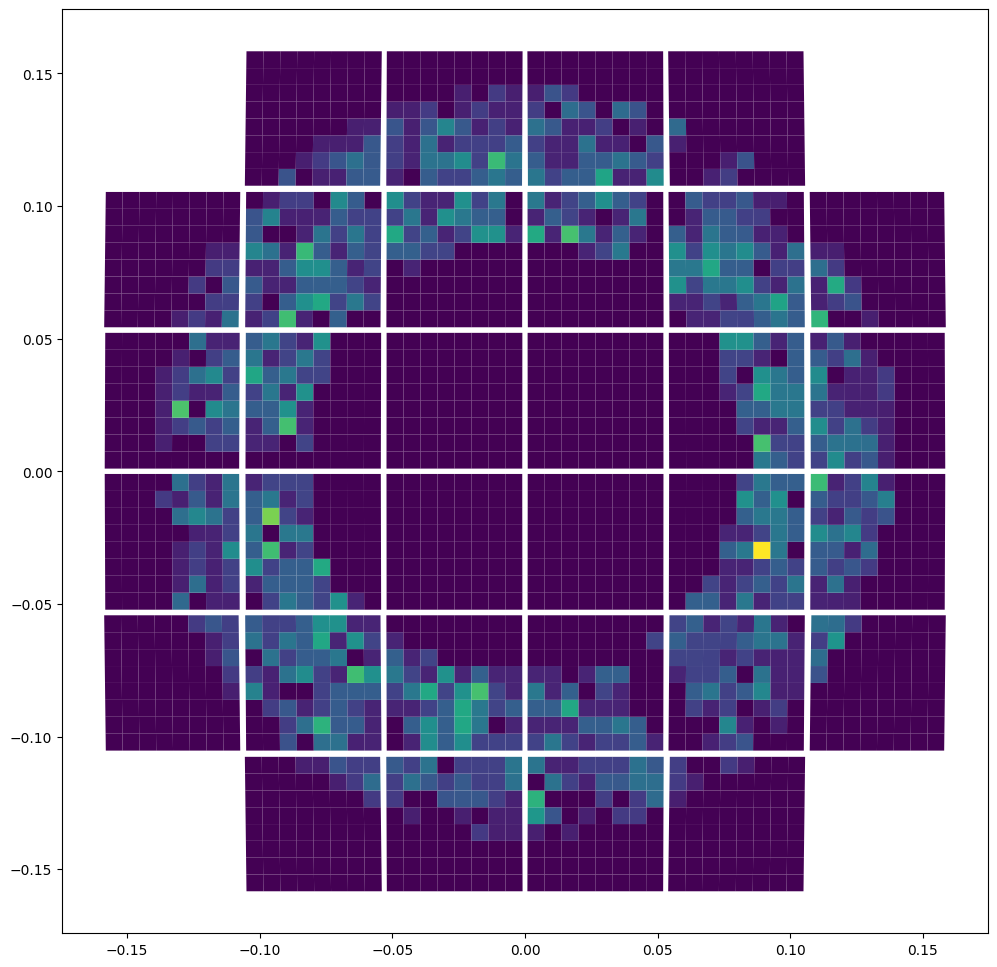

In [5]:
N_points = 1
key1, key2 = jax.random.split(jax.random.key(45))

x = jax.random.uniform(key1, N_points, minval=-0.1, maxval=0.1)
y = jax.random.uniform(key2, N_points, minval=-0.1, maxval=0.1)
z = jnp.ones(N_points) * 30

points = jnp.array([x, y, z]).T
f_points = jnp.ones(len(points))

rays = telescope.render(points, f_points, source_type='point')
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_camera(image, camera.sensor_groups[0], ax=ax)

## Spot diagram

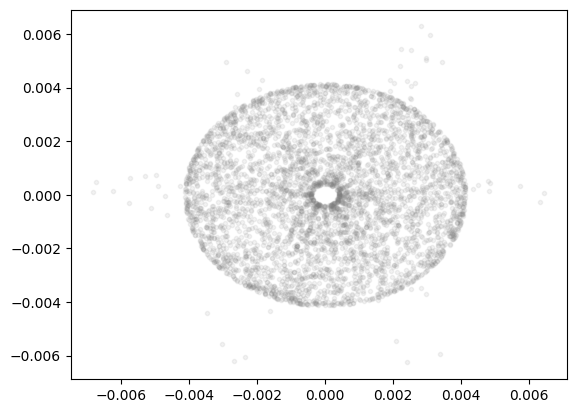

In [6]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace.analysis import AsphericFocalSurface

stars = jnp.array([[0.00, -0.00, -1]])
stars = stars/jnp.linalg.norm(stars)
f_stars = jnp.array([1.0])
rays = telescope.render(stars, f_stars, source_type='parallel')

focal_plane = AsphericFocalSurface(curvature=-1/1.06)

hits = focal_plane.intersect(rays)
plt.scatter(hits.xy_local[:,0], hits.xy_local[:,1], alpha=0.1, color='gray', marker='.')

## PSF properties
We can calculate the r80 value depending on off-axis angle and compare to literature:

In [7]:
import numpy as np


def calculate_r80(hits):
    x = hits.xy_local[:,0][hits.hit_mask]
    y = hits.xy_local[:,1][hits.hit_mask]
    w = rays.materialise().values[hits.hit_mask]

    cx = np.average(x, weights=w)
    cy = np.average(y, weights=w)
    r = np.hypot(x - cx, y - cy)

    idx = np.argsort(r)
    cum = np.cumsum(w[idx]) / w.sum()
    r80 = np.interp(0.8, cum, r[idx])

    return r80

Checking depending on off-axis angle:

In [8]:
r80s = []
angles = []
for i in np.linspace(0.0,0.083,15):
    stars = jnp.array([[0.0, i, -1]])
    stars = stars/jnp.linalg.norm(stars)
    f_stars = jnp.array([1.0])
    rays = telescope.render(stars, f_stars, source_type='parallel')
    hits = focal_plane.intersect(rays)

    angles.append(np.rad2deg(np.arctan(stars[0][1]/stars[0][-1])))
    r80s.append(calculate_r80(hits))

Multiplied with the plate scale multiplied by two to get d80:

Text(0, 0.5, 'd80 [deg]')

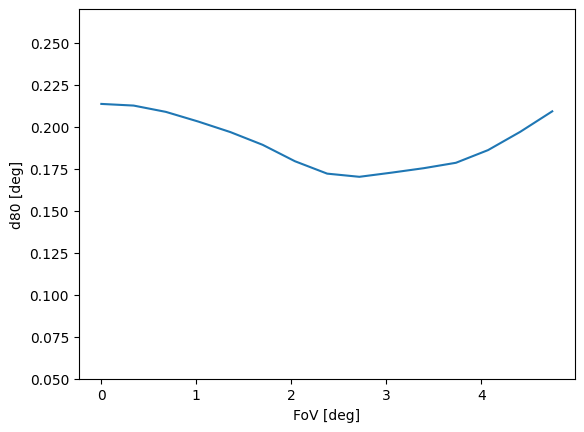

In [9]:
plt.plot(np.abs(angles), 2*np.array(r80s)*1e3/37.53)
plt.ylim(0.05,0.27)
plt.xlabel('FoV [deg]')
plt.ylabel('d80 [deg]')

The reason for the difference to the literature is our assumed 3.5mm fused silica window adding refraction and thus shifting the effective focal point. If we remove the window, we get the same values as in literature:

In [10]:
import equinox as eqx

jax.clear_caches()

tel_no_window = eqx.tree_at(lambda t: t.lens_groups, telescope, [])

no_w_r80s = []
angles = []
for i in np.linspace(0.0,0.083,15):
    stars = jnp.array([[0.0, i, -1]])
    stars = stars/jnp.linalg.norm(stars)
    f_stars = jnp.array([1.0])
    rays = tel_no_window.render(stars, f_stars, source_type='parallel')
    hits = focal_plane.intersect(rays)

    angles.append(np.rad2deg(np.arctan(stars[0][1]/stars[0][-1])))
    no_w_r80s.append(calculate_r80(hits))

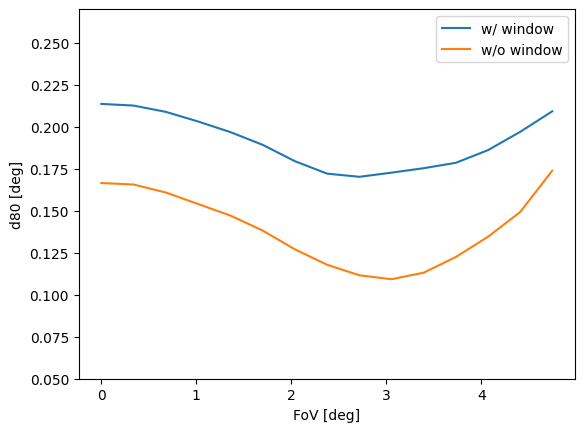

In [11]:
plt.plot(np.abs(angles), 2*np.array(r80s)*1e3/37.53, label='w/ window')
plt.plot(np.abs(angles), 2*np.array(no_w_r80s)*1e3/37.53, label='w/o window')
plt.xlabel('FoV [deg]')
plt.ylabel('d80 [deg]')
plt.ylim(0.05,0.27)
plt.legend()

We can try and recover a new focal position by doing a focal scan:

In [12]:
jax.clear_caches()
r80s = []
fz = np.linspace(-4e-3, 0e-3, 15)
for i in fz:
    new_tel = telescope.focus(i)
    rays = new_tel.render(stars, f_stars, source_type='parallel')
    hits = focal_plane.intersect(rays)
    r80s.append(calculate_r80(hits))

Text(0, 0.5, 'd80 [deg]')

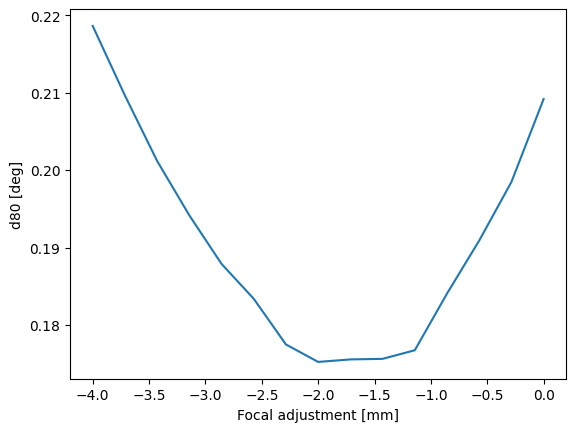

In [13]:
plt.plot(fz*1e3, 2*np.array(r80s)*1e3/37.53)
plt.xlabel('Focal adjustment [mm]')
plt.ylabel('d80 [deg]')

We can see that we should probably adjust the position of our camera by ~2mm due to the window compared to the nominal value.